In [1]:
%load_ext autoreload
%autoreload 2

from seek_code import SEEK
from backbone import Backbone
from retrieval import Retrieval
from projector import Projector
from data_handler import EleHandler
from concept_head_tunneled import ConceptHeadTunneled, categorical_CE_loss, CrossedHeadNN, MultiHeadNN

from pathlib import Path
from torch.utils.data import DataLoader, Subset

dataset = EleHandler(subset='IDI_6')
train_indices, test_indices = dataset.split_perpendicular_to_elephants_and_encounters(split_sizes=[0.5,0.5], hour_delta = 0.2)

train_subset = Subset(dataset, train_indices)
test_subset = Subset(dataset, test_indices)

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=True)

/data/vision/beery/scratch/antoine/micromamba/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Exp 1 : Querying with extracted (pretty bad) SEEK codes

The query is simply the extracted SEEK code. The database is :
1. extracted SEEK codes
2. aggregated extracted SEEK codes
3. image-wise corrected SEEK codes
4. aggregated image-wise SEEK codes
5. Oracle SEEK codes

In [2]:
code ='concept-exp1'
r = Retrieval()

MD_for_concepts = Backbone(model_name="MegaDescriptor", pretraining="backbone_for_concepts_w", experiment_code=code)
concept_head = ConceptHeadTunneled(loss=categorical_CE_loss, experiment_code = code, layer = CrossedHeadNN(), reset_weights=False, pretraining='concept_w')


/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

Concept head loaded from /data/vision/beery/scratch/antoine/CBM_reid/weights/concept_w.pt


/data/vision/beery/scratch/antoine/CBM_reid/methods/concept_head_tunneled.py:423: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(path, map_loc

In [3]:
# Collect embeddings and compute similarity matrix
query_embeddings, query_labels = concept_head.collect_embeddings(test_loader, backbone=MD_for_concepts, intervention_fn=None, aggregate_seeks=None)
gallery_embeddings, gallery_labels = concept_head.collect_embeddings(train_loader, backbone=MD_for_concepts, intervention_fn= None, aggregate_seeks=False)
test_similarity_matrix = r.similarity_matrix(query_embeddings, gallery_embeddings, distance = 'seek_homemade_3')

# Compute and print recalls
test_recalls = {k: r.compute_recall_at_k(similarity_matrix=test_similarity_matrix, query_labels=query_labels, gallery_labels=gallery_labels, k=k) for k in [1,5,10,20,100]}
for k in [1,5,10,20,100]: print(f"Recall@{k}: {test_recalls[k]*100:.2f}%")

Recall@1: 0.99%
Recall@5: 3.20%
Recall@10: 5.56%
Recall@20: 9.44%
Recall@100: 28.64%


In [4]:
# Collect embeddings and compute similarity matrix
query_embeddings, query_labels = concept_head.collect_embeddings(test_loader, backbone=MD_for_concepts, intervention_fn=None, aggregate_seeks=None)
gallery_embeddings, gallery_labels = concept_head.collect_embeddings(train_loader, backbone=MD_for_concepts, intervention_fn= None, aggregate_seeks=True)
test_similarity_matrix = r.similarity_matrix(query_embeddings, gallery_embeddings, distance = 'seek_homemade_3')

# Compute and print recalls
test_recalls = {k: r.compute_recall_at_k(similarity_matrix=test_similarity_matrix, query_labels=query_labels, gallery_labels=gallery_labels, k=k) for k in [1,5,10,20,100]}
for k in [1,5,10,20,100]: print(f"Recall@{k}: {test_recalls[k]*100:.2f}%")

Recall@1: 1.37%
Recall@5: 3.66%
Recall@10: 4.72%
Recall@20: 5.86%
Recall@100: 12.11%


In [5]:
# Collect embeddings and compute similarity matrix
query_embeddings, query_labels = concept_head.collect_embeddings(test_loader, backbone=MD_for_concepts, intervention_fn=None, aggregate_seeks=None)
gallery_embeddings, gallery_labels = concept_head.collect_embeddings(train_loader, backbone=MD_for_concepts, intervention_fn=SEEK.perfect_correction, aggregate_seeks=False)
test_similarity_matrix = r.similarity_matrix(query_embeddings, gallery_embeddings, distance='seek_homemade_3')

# Compute and print recalls
test_recalls = {k: r.compute_recall_at_k(similarity_matrix=test_similarity_matrix, query_labels=query_labels, gallery_labels=gallery_labels, k=k) for k in [1,5,10,20,100]}
for k in [1,5,10,20,100]: print(f"Recall@{k}: {test_recalls[k]*100:.2f}%")

Recall@1: 0.30%
Recall@5: 2.06%
Recall@10: 3.96%
Recall@20: 7.77%
Recall@100: 31.68%


In [6]:
# Collect embeddings and compute similarity matrix
query_embeddings, query_labels = concept_head.collect_embeddings(test_loader, backbone=MD_for_concepts, intervention_fn=None, aggregate_seeks=None)
gallery_embeddings, gallery_labels = concept_head.collect_embeddings(train_loader, backbone=MD_for_concepts, intervention_fn= SEEK.perfect_correction, aggregate_seeks=True)
test_similarity_matrix = r.similarity_matrix(query_embeddings, gallery_embeddings, distance = 'seek_homemade_3')

# Compute and print recalls
test_recalls = {k: r.compute_recall_at_k(similarity_matrix=test_similarity_matrix, query_labels=query_labels, gallery_labels=gallery_labels, k=k) for k in [1,5,10,20,100]}
for k in [1,5,10,20,100]: print(f"Recall@{k}: {test_recalls[k]*100:.2f}%")

Recall@1: 0.69%
Recall@5: 1.07%
Recall@10: 1.52%
Recall@20: 1.98%
Recall@100: 7.92%


In [7]:
# Collect embeddings and compute similarity matrix
query_embeddings, query_labels = concept_head.collect_embeddings(test_loader, backbone=MD_for_concepts, intervention_fn=None, aggregate_seeks=None)
gallery_embeddings, gallery_labels = concept_head.collect_embeddings(train_loader, backbone=MD_for_concepts, intervention_fn= SEEK.oracle_correction, aggregate_seeks=False)
test_similarity_matrix = r.similarity_matrix(query_embeddings, gallery_embeddings, distance = 'seek_homemade_3')

# Compute and print recalls
test_recalls = {k: r.compute_recall_at_k(similarity_matrix=test_similarity_matrix, query_labels=query_labels, gallery_labels=gallery_labels, k=k) for k in [1,5,10,20,100]}
for k in [1,5,10,20,100]: print(f"Recall@{k}: {test_recalls[k]*100:.2f}%")

Recall@1: 1.14%
Recall@5: 1.98%
Recall@10: 2.21%
Recall@20: 2.89%
Recall@100: 11.12%


# Exp 2 : Querying with image-wise corrected SEEK codes

The query is the image-corrected SEEK code. The database is :
1. aggregated extracted SEEK codes 
2. image-wise corrected SEEK codes (same treatment as query)
3. aggregated image-wise SEEK codes
4. Oracle SEEK codes 

In [8]:
code ='concept-exp2'
r = Retrieval()

MD_for_concepts = Backbone(model_name="MegaDescriptor", pretraining="backbone_for_concepts_w", experiment_code=code)
concept_head = ConceptHeadTunneled(loss=categorical_CE_loss, experiment_code = code, layer = CrossedHeadNN(), reset_weights=False, pretraining='concept_w')

query_embeddings, query_labels = concept_head.collect_embeddings(test_loader, backbone=MD_for_concepts, intervention_fn=SEEK.perfect_correction, aggregate_seeks=False)
gallery_embeddings, gallery_labels = concept_head.collect_embeddings(train_loader, backbone=MD_for_concepts, intervention_fn= None, aggregate_seeks=True)
test_similarity_matrix = r.similarity_matrix(query_embeddings, gallery_embeddings, distance='seek_homemade_3')

# Compute and print recalls
test_recalls = {k: r.compute_recall_at_k(similarity_matrix=test_similarity_matrix, query_labels=query_labels, gallery_labels=gallery_labels, k=k) for k in [1,5,10,20,100]}
for k in [1,5,10,20,100]: print(f"Recall@{k}: {test_recalls[k]*100:.2f}%")

/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

Concept head loaded from /data/vision/beery/scratch/antoine/CBM_reid/weights/concept_w.pt
Recall@1: 2.82%
Recall@5: 6.85%
Recall@10: 10.13%
Recall@20: 16.37%
Recall@100: 32.90%


In [9]:
code ='concept-exp2'
r = Retrieval()

MD_for_concepts = Backbone(model_name="MegaDescriptor", pretraining="backbone_for_concepts_w", experiment_code=code)
concept_head = ConceptHeadTunneled(loss=categorical_CE_loss, experiment_code = code, layer = CrossedHeadNN(), reset_weights=False, pretraining='concept_w')

query_embeddings, query_labels = concept_head.collect_embeddings(test_loader, backbone=MD_for_concepts, intervention_fn=SEEK.perfect_correction, aggregate_seeks=False)
gallery_embeddings, gallery_labels = concept_head.collect_embeddings(train_loader, backbone=MD_for_concepts, intervention_fn=SEEK.perfect_correction, aggregate_seeks=False)
test_similarity_matrix = r.similarity_matrix(query_embeddings, gallery_embeddings, distance='seek_homemade_3')

# Compute and print recalls
test_recalls = {k: r.compute_recall_at_k(similarity_matrix=test_similarity_matrix, query_labels=query_labels, gallery_labels=gallery_labels, k=k) for k in [1,5,10,20,100]}
for k in [1,5,10,20,100]: print(f"Recall@{k}: {test_recalls[k]*100:.2f}%")

/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

Concept head loaded from /data/vision/beery/scratch/antoine/CBM_reid/weights/concept_w.pt
Recall@1: 4.95%
Recall@5: 13.25%
Recall@10: 19.65%
Recall@20: 27.80%
Recall@100: 59.25%


In [10]:
code ='concept-exp2'
r = Retrieval()

MD_for_concepts = Backbone(model_name="MegaDescriptor", pretraining="backbone_for_concepts_w", experiment_code=code)
concept_head = ConceptHeadTunneled(loss=categorical_CE_loss, experiment_code = code, layer = CrossedHeadNN(), reset_weights=False, pretraining='concept_w')

query_embeddings, query_labels = concept_head.collect_embeddings(test_loader, backbone=MD_for_concepts, intervention_fn=SEEK.perfect_correction, aggregate_seeks=False)
gallery_embeddings, gallery_labels = concept_head.collect_embeddings(train_loader, backbone=MD_for_concepts, intervention_fn=SEEK.perfect_correction, aggregate_seeks=True)
test_similarity_matrix = r.similarity_matrix(query_embeddings, gallery_embeddings, distance='seek_homemade_3')

# Compute and print recalls
test_recalls = {k: r.compute_recall_at_k(similarity_matrix=test_similarity_matrix, query_labels=query_labels, gallery_labels=gallery_labels, k=k) for k in [1,5,10,20,100]}
for k in [1,5,10,20,100]: print(f"Recall@{k}: {test_recalls[k]*100:.2f}%")

Concept head loaded from /data/vision/beery/scratch/antoine/CBM_reid/weights/concept_w.pt
Recall@1: 3.96%
Recall@5: 7.01%
Recall@10: 8.83%
Recall@20: 13.18%
Recall@100: 27.04%


In [11]:
code ='concept-exp2'
r = Retrieval()

MD_for_concepts = Backbone(model_name="MegaDescriptor", pretraining="backbone_for_concepts_w", experiment_code=code)
concept_head = ConceptHeadTunneled(loss=categorical_CE_loss, experiment_code = code, layer = CrossedHeadNN(), reset_weights=False, pretraining='concept_w')

query_embeddings, query_labels = concept_head.collect_embeddings(test_loader, backbone=MD_for_concepts, intervention_fn=SEEK.perfect_correction, aggregate_seeks=False)
gallery_embeddings, gallery_labels = concept_head.collect_embeddings(train_loader, backbone=MD_for_concepts, intervention_fn=SEEK.oracle_correction, aggregate_seeks=False)
test_similarity_matrix = r.similarity_matrix(query_embeddings, gallery_embeddings, distance='seek_homemade_3')

# Compute and print recalls
test_recalls = {k: r.compute_recall_at_k(similarity_matrix=test_similarity_matrix, query_labels=query_labels, gallery_labels=gallery_labels, k=k) for k in [1,5,10,20,100]}
for k in [1,5,10,20,100]: print(f"Recall@{k}: {test_recalls[k]*100:.2f}%")

/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

Concept head loaded from /data/vision/beery/scratch/antoine/CBM_reid/weights/concept_w.pt
Recall@1: 6.40%
Recall@5: 10.97%
Recall@10: 17.29%
Recall@20: 23.23%
Recall@100: 44.10%


# Exp 3 : Querying with Oracle concepts

The query is the oracle-corrected SEEK code. The database is :
1. image-wise corrected SEEK codes 
2. aggregated image-wise SEEK codes
3. Oracle SEEK codes 

In [13]:
code ='concept-exp3'
r = Retrieval()

MD_for_concepts = Backbone(model_name="MegaDescriptor", pretraining="backbone_for_concepts_w", experiment_code=code)
concept_head = ConceptHeadTunneled(loss=categorical_CE_loss, experiment_code = code, layer = CrossedHeadNN(), reset_weights=False, pretraining='concept_w')

query_embeddings, query_labels = concept_head.collect_embeddings(test_loader, backbone=MD_for_concepts, intervention_fn=SEEK.oracle_correction, aggregate_seeks=False)
gallery_embeddings, gallery_labels = concept_head.collect_embeddings(train_loader, backbone=MD_for_concepts, intervention_fn=SEEK.perfect_correction, aggregate_seeks=False)
test_similarity_matrix = r.similarity_matrix(query_embeddings, gallery_embeddings, distance='seek_homemade_3')

# Compute and print recalls
test_recalls = {k: r.compute_recall_at_k(similarity_matrix=test_similarity_matrix, query_labels=query_labels, gallery_labels=gallery_labels, k=k) for k in [1,5,10,20,100]}
for k in [1,5,10,20,100]: print(f"Recall@{k}: {test_recalls[k]*100:.2f}%")

Concept head loaded from /data/vision/beery/scratch/antoine/CBM_reid/weights/concept_w.pt
Recall@1: 11.65%
Recall@5: 27.88%
Recall@10: 37.40%
Recall@20: 53.24%
Recall@100: 83.24%


In [14]:
code ='concept-exp3'
r = Retrieval()

MD_for_concepts = Backbone(model_name="MegaDescriptor", pretraining="backbone_for_concepts_w", experiment_code=code)
concept_head = ConceptHeadTunneled(loss=categorical_CE_loss, experiment_code = code, layer = CrossedHeadNN(), reset_weights=False, pretraining='concept_w')

query_embeddings, query_labels = concept_head.collect_embeddings(test_loader, backbone=MD_for_concepts, intervention_fn=SEEK.oracle_correction, aggregate_seeks=False)
gallery_embeddings, gallery_labels = concept_head.collect_embeddings(train_loader, backbone=MD_for_concepts, intervention_fn=SEEK.perfect_correction, aggregate_seeks=True)
test_similarity_matrix = r.similarity_matrix(query_embeddings, gallery_embeddings, distance='seek_homemade_3')

# Compute and print recalls
test_recalls = {k: r.compute_recall_at_k(similarity_matrix=test_similarity_matrix, query_labels=query_labels, gallery_labels=gallery_labels, k=k) for k in [1,5,10,20,100]}
for k in [1,5,10,20,100]: print(f"Recall@{k}: {test_recalls[k]*100:.2f}%")

Concept head loaded from /data/vision/beery/scratch/antoine/CBM_reid/weights/concept_w.pt
Recall@1: 15.69%
Recall@5: 22.16%
Recall@10: 28.94%
Recall@20: 41.05%
Recall@100: 61.46%


In [15]:
code ='concept-exp3'
r = Retrieval()

MD_for_concepts = Backbone(model_name="MegaDescriptor", pretraining="backbone_for_concepts_w", experiment_code=code)
concept_head = ConceptHeadTunneled(loss=categorical_CE_loss, experiment_code = code, layer = CrossedHeadNN(), reset_weights=False, pretraining='concept_w')

query_embeddings, query_labels = concept_head.collect_embeddings(test_loader, backbone=MD_for_concepts, intervention_fn=SEEK.oracle_correction, aggregate_seeks=False)
gallery_embeddings, gallery_labels = concept_head.collect_embeddings(train_loader, backbone=MD_for_concepts, intervention_fn=SEEK.oracle_correction, aggregate_seeks=False)
test_similarity_matrix = r.similarity_matrix(query_embeddings, gallery_embeddings, distance='seek_homemade_3')

# Compute and print recalls
test_recalls = {k: r.compute_recall_at_k(similarity_matrix=test_similarity_matrix, query_labels=query_labels, gallery_labels=gallery_labels, k=k) for k in [1,5,10,20,100]}
for k in [1,5,10,20,100]: print(f"Recall@{k}: {test_recalls[k]*100:.2f}%")

/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

Concept head loaded from /data/vision/beery/scratch/antoine/CBM_reid/weights/concept_w.pt
Recall@1: 81.65%
Recall@5: 96.34%
Recall@10: 99.39%
Recall@20: 100.00%
Recall@100: 100.00%


# Exp 4 : size of query and galery set

In [ ]:
import torch

scenarios = {
    'NO CORRECTION ON QUERIES': None,
    'IMAGE-WISE CORRECTION ON QUERIES': SEEK.perfect_correction,
    'ORACLE TREATMENT ON QUERIES': SEEK.oracle_correction,
}

MD_for_concepts = Backbone(model_name="MegaDescriptor", pretraining="backbone_for_concepts_w", experiment_code=code)
concept_head = ConceptHeadTunneled(loss=categorical_CE_loss,experiment_code=code,layer=CrossedHeadNN(),reset_weights=False, pretraining='concept_w')

for title, fn in scenarios.items():
    q_emb, q_labels = concept_head.collect_embeddings(test_loader, backbone=MD_for_concepts, intervention_fn=fn, aggregate_seeks=False)
    q_labels = torch.as_tensor(q_labels)  # ensure tensor for .unique()

    print(title)
    print('number of queries ?', len(q_emb))
    print('number of different elephants in the query set ?', q_labels.unique().numel())
    print('number of unique SEEK codes in the query set ?', torch.unique(q_emb, dim=0).size(0))


/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

Concept head loaded from /data/vision/beery/scratch/antoine/CBM_reid/weights/concept_w.pt
NO CORRECTION ON QUERIES
number of queries ? 1313
number of different elephants in the query set ? 310
number of unique SEEK codes in the query set ? 108
Concept head loaded from /data/vision/beery/scratch/antoine/CBM_reid/weights/concept_w.pt
IMAGE-WISE CORRECTION ON QUERIES
number of queries ? 1313
number of different elephants in the query set ? 310
number of unique SEEK codes in the query set ? 777
Concept head loaded from /data/vision/beery/scratch/antoine/CBM_reid/weights/concept_w.pt
ORACLE TREATMENT ON QUERIES
number of queries ? 1313
number of different elephants in the query set ? 310
number of unique SEEK codes in the query set ? 248


In [83]:
import torch

scenarios = {
    'NO CORRECTION ON GALLERY': (None, False),
    'NO CORRECTION + AGGREGATION ON GALLERY': (None, True),
    'IMAGE CORRECTION ON GALLERY': (SEEK.perfect_correction, False),
    'IMAGE CORRECTION + AGGREGATION ON GALLERY': (SEEK.perfect_correction, True),
    'ORACLE CORRECTION ON GALLERY': (SEEK.oracle_correction, False),
}

MD_for_concepts = Backbone(model_name="MegaDescriptor",
                           pretraining="backbone_for_concepts_w",
                           experiment_code=code)
concept_head = ConceptHeadTunneled(loss=categorical_CE_loss,
                                   experiment_code=code,
                                   layer=CrossedHeadNN(),
                                   reset_weights=False,
                                   pretraining='concept_w')

for title, (fn, agg) in scenarios.items():
    g_emb, g_labels = concept_head.collect_embeddings(
        train_loader,
        backbone=MD_for_concepts,
        intervention_fn=fn,
        aggregate_seeks=agg
    )
    g_labels = torch.as_tensor(g_labels)  # ensure tensor for .unique()

    print(title)
    print('size of the database ?', len(g_emb))
    print('number of different elephants in the gallery set ?', g_labels.unique().numel())
    print('number of different SEEK codes in the gallery ?', torch.unique(g_emb, dim=0).size(0))


Concept head loaded from /data/vision/beery/scratch/antoine/CBM_reid/weights/concept_w.pt
NO CORRECTION ON GALLERY
size of the database ? 1981
number of different elephants in the gallery set ? 310
number of different SEEK codes in the gallery ? 316
NO CORRECTION + AGGREGATION ON GALLERY
size of the database ? 1981
number of different elephants in the gallery set ? 310
number of different SEEK codes in the gallery ? 119
IMAGE CORRECTION ON GALLERY
size of the database ? 1981
number of different elephants in the gallery set ? 310
number of different SEEK codes in the gallery ? 1061
IMAGE CORRECTION + AGGREGATION ON GALLERY
size of the database ? 1981
number of different elephants in the gallery set ? 310
number of different SEEK codes in the gallery ? 267
ORACLE CORRECTION ON GALLERY
size of the database ? 1981
number of different elephants in the gallery set ? 310
number of different SEEK codes in the gallery ? 248


# Examples

In [1]:
%load_ext autoreload
%autoreload 2

from seek_code import SEEK
from backbone import Backbone
from retrieval import Retrieval
from projector import Projector
from data_handler import EleHandler
from concept_head_tunneled import ConceptHeadTunneled, categorical_CE_loss, CrossedHeadNN, MultiHeadNN

from pathlib import Path
from torch.utils.data import DataLoader, Subset

dataset = EleHandler(subset='IDI_6')
train_indices, test_indices = dataset.split_perpendicular_to_elephants_and_encounters(split_sizes=[0.5,0.5], hour_delta = 0.2)

train_subset = Subset(dataset, train_indices)
test_subset = Subset(dataset, test_indices)

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=True)

/data/vision/beery/scratch/antoine/micromamba/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
code = 'debug'
MD_for_concepts = Backbone(model_name="MegaDescriptor", pretraining="backbone_for_concepts_w", experiment_code=code)
concept_head = ConceptHeadTunneled(loss=categorical_CE_loss, experiment_code = code, layer = CrossedHeadNN(), reset_weights=False, pretraining='concept_w')
r = Retrieval()

query_embeddings, query_labels = concept_head.collect_embeddings(test_loader, backbone=MD_for_concepts, intervention_fn=SEEK.oracle_correction, aggregate_seeks=False)
gallery_embeddings, gallery_labels = concept_head.collect_embeddings(train_loader, backbone=MD_for_concepts, intervention_fn=SEEK.oracle_correction, aggregate_seeks=False)
test_similarity_matrix = r.similarity_matrix(query_embeddings, gallery_embeddings, distance='seek_homemade_3')

/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

Concept head loaded from /data/vision/beery/scratch/antoine/CBM_reid/weights/concept_w.pt


In [3]:
import torch
import pandas as pd
import numpy as np

def collect_all_SEEKs(MD_for_concepts, concept_head, loader, device=None):
    device = device or ('cuda' if torch.cuda.is_available() else 'cpu')

    extracted_list, corrected_list, oracle_list = [], [], []
    labels_list, indices_list = [], []

    with torch.no_grad():
        for batch in loader:
            images            = batch[0].to(device)
            ele_id_label      = batch[2].to(device).long()
            subject_SEEK_1hot = batch[4].to(device).float()
            ele_SEEK_1hot     = batch[5].to(device).float()
            left_ears         = batch[6].to(device)
            right_ears        = batch[7].to(device)
            idx               = batch[10].to(device).long()

            embeddings = MD_for_concepts(images, left_ears, right_ears)
            outputs    = concept_head.layer(embeddings)

            hard_extracted_SEEK = SEEK.closest_valid_one_hot(outputs).float()
            corrected_SEEK      = SEEK.perfect_correction(hard_extracted_SEEK, subject_SEEK_1hot, ele_SEEK_1hot).float()
            oracle_SEEK         = ele_SEEK_1hot

            extracted_list.append(hard_extracted_SEEK)
            corrected_list.append(corrected_SEEK)
            oracle_list.append(oracle_SEEK)
            labels_list.append(ele_id_label)
            indices_list.append(idx)

    collected_extracted_SEEK = torch.cat(extracted_list, dim=0) if extracted_list else torch.empty(0, 63, device=device)
    collected_corrected_SEEK = torch.cat(corrected_list, dim=0) if corrected_list else torch.empty(0, 63, device=device)
    collected_oracle_SEEK    = torch.cat(oracle_list,    dim=0) if oracle_list    else torch.empty(0, 63, device=device)
    collected_labels         = torch.cat(labels_list,    dim=0) if labels_list    else torch.empty(0,    dtype=torch.long, device=device)
    collected_indices        = torch.cat(indices_list,   dim=0) if indices_list   else torch.empty(0,    dtype=torch.long, device=device)

    subj_ext, agg_ext, _ = SEEK.aggregate_seek(collected_extracted_SEEK, collected_labels)
    subj_cor, agg_cor, _ = SEEK.aggregate_seek(collected_corrected_SEEK, collected_labels)

    def vec_to_seek_str(vec1d):
        one_hot = SEEK.closest_valid_one_hot(vec1d.unsqueeze(0)).squeeze(0)
        return str(SEEK(one_hot))

    np_idx = collected_indices.detach().cpu().numpy()
    np_lab = collected_labels.detach().cpu().numpy()

    ex_str  = [vec_to_seek_str(v) for v in collected_extracted_SEEK.detach().cpu()]
    co_str  = [vec_to_seek_str(v) for v in collected_corrected_SEEK.detach().cpu()]
    or_str  = [vec_to_seek_str(v) for v in collected_oracle_SEEK.detach().cpu()]
    agg_ex_str = [vec_to_seek_str(v) for v in agg_ext.detach().cpu()]
    agg_co_str = [vec_to_seek_str(v) for v in agg_cor.detach().cpu()]

    df = pd.DataFrame({
        "image_idx": np_idx,
        "ele_id_label": np_lab,
        "extracted_seek_str": ex_str,
        "corrected_seek_str": co_str,
        "oracle_seek_str": or_str,
        "agg_extracted_seek_str": agg_ex_str,
        "agg_corrected_seek_str": agg_co_str,
    })
    return df


In [5]:
DF = collect_all_SEEKs(MD_for_concepts, concept_head, train_loader, device='cuda')
DF.sort_values('ele_id_label')

,image_idx,ele_id_label,extracted_seek_str,corrected_seek_str,oracle_seek_str,agg_extracted_seek_str,agg_corrected_seek_str
1602,36,0,B00T11E8080-4000X_0S00,B00T11E____-4030X_0S00,B00T11E8080-4030X_0S00,B00T11E8080-4000X_0S00,B00T11E8080-4030X00S00
1786,20,0,B00T11E8080-3000X_0S00,B00T11E____-4050X_0S00,B00T11E8080-4030X_0S00,B00T11E8080-4000X_0S00,B00T11E8080-4030X00S00
324,16,0,B00T11E8000-4000X_0S00,B00T11E7080-0000X00S00,B00T11E8080-4030X_0S00,B00T11E8080-4000X_0S00,B00T11E8080-4030X00S00
503,8,0,B00T11E8080-4000X_0S00,B00T11E____-4530X_0S_0,B00T11E8080-4030X_0S00,B00T11E8080-4000X_0S00,B00T11E8080-4030X00S00
1285,6,0,B00T11E9080-4000X_0S00,B00T1_E8080-____X0_S00,B00T11E8080-4030X_0S00,B00T11E8080-4000X_0S00,B00T11E8080-4030X00S00
...,...,...,...,...,...,...,...
1010,3284,309,B00T11E0000-0000X0_S00,B00T11E0000-____X0_S00,B00T11E0000-0000X0_S00,B00T11E0000-0000X0_S00,B00T11E0000-3000X00S00
310,3292,309,B00T11E0000-0000X0_S00,B00T1_E0000-____X0_S00,B00T11E0000-0000X0_S00,B00T11E0000-0000X0_S00,B00T11E0000-3000X00S00
1290,3290,309,B00T11E0000-0000X0_S00,B00T11E0000-3000X00S00,B00T11E0000-0000X0_S00,B00T11E0000-0000X0_S00,B00T11E0000-3000X00S00
1306,3286,309,B00T11E0000-0000X0_S00,B00T11E0000-4000X00S00,B00T11E0000-0000X0_S00,B00T11E0000-0000X0_S00,B00T11E0000-3000X00S00


Elephant ID: 3, Number of images: 4
extracted_SEEK=       B00T11E8080-4000X_0S00,
 agg_extracted_SEEK=  B00T11E8000-4030X_0S00, 
 corrected_SEEK=      B00T01E____-4000X_0S00, 
 agg_corr_SEEK=       B00T01E8977-4333X00S00, 
 oracle_SEEK=         B00T01E8070-4330X_0S00


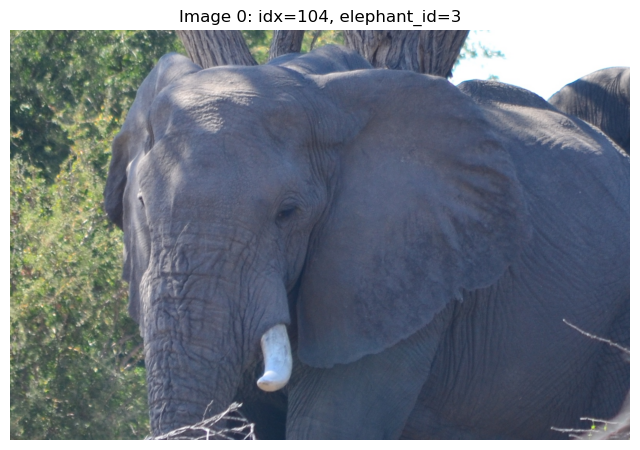

extracted_SEEK=       B00T11E8000-4030X_0S00,
 agg_extracted_SEEK=  B00T11E8000-4030X_0S00, 
 corrected_SEEK=      B00T0_E8000-4333X00S00, 
 agg_corr_SEEK=       B00T01E8977-4333X00S00, 
 oracle_SEEK=         B00T01E8070-4330X_0S00


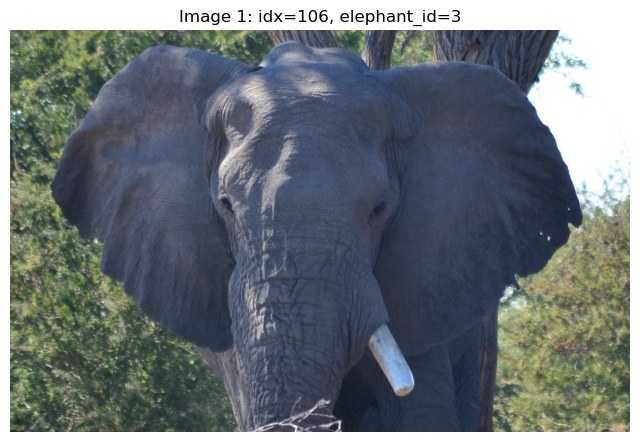

extracted_SEEK=       B00T11E8000-4000X_0S00,
 agg_extracted_SEEK=  B00T11E8000-4030X_0S00, 
 corrected_SEEK=      B00T_1E8977-5030X_0S00, 
 agg_corr_SEEK=       B00T01E8977-4333X00S00, 
 oracle_SEEK=         B00T01E8070-4330X_0S00


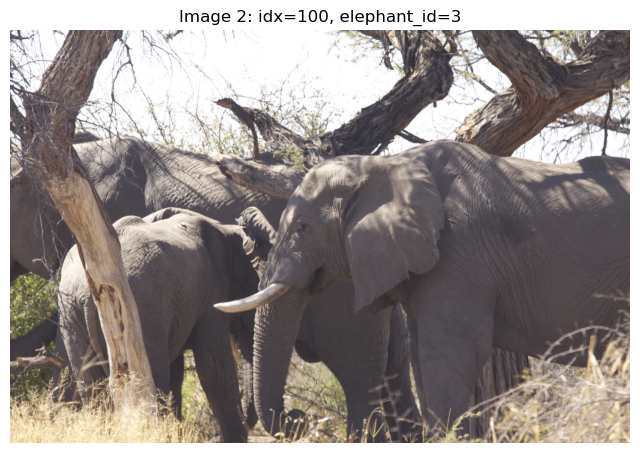

extracted_SEEK=       B00T_1E8000-4040X_0S00,
 agg_extracted_SEEK=  B00T11E8000-4030X_0S00, 
 corrected_SEEK=      B00T01E8070-____X0_S00, 
 agg_corr_SEEK=       B00T01E8977-4333X00S00, 
 oracle_SEEK=         B00T01E8070-4330X_0S00


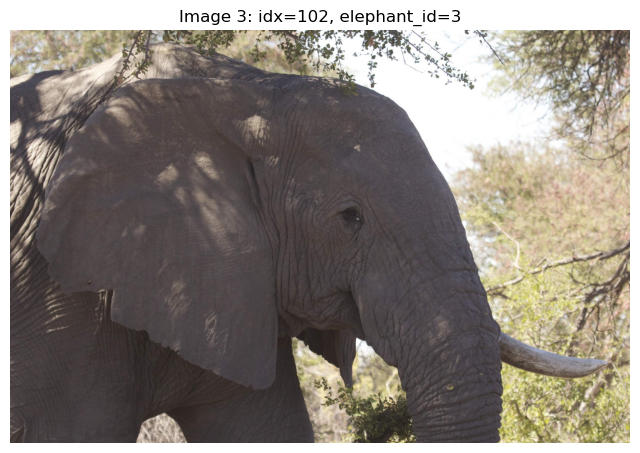

In [6]:

def display_elephant_images(DF, dataset, elephant_id):
    import matplotlib.pyplot as plt
    DF_ele = DF[DF['ele_id_label'] == elephant_id].reset_index(drop=True)
    print(f"Elephant ID: {elephant_id}, Number of images: {len(DF_ele)}")
    for i in range(len(DF_ele)):
        img = dataset.get_original_image(idx=DF_ele.loc[i, 'image_idx'])
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.title(f"Image {i}: idx={DF_ele.loc[i, 'image_idx']}, elephant_id={DF_ele.loc[i, 'ele_id_label']}")
        plt.axis('off')
        print(f"extracted_SEEK=       {DF_ele.loc[i, 'extracted_seek_str']},\n agg_extracted_SEEK=  {DF_ele.loc[i, 'agg_extracted_seek_str']}, \n corrected_SEEK=      {DF_ele.loc[i, 'corrected_seek_str']}, \n agg_corr_SEEK=       {DF_ele.loc[i, 'agg_corrected_seek_str']}, \n oracle_SEEK=         {DF_ele.loc[i, 'oracle_seek_str']}")
        plt.show()
display_elephant_images(DF, dataset, elephant_id=3)

In [ ]:
display_elephant_images(DF, dataset, elephant_id=8)

NameError: name 'display_elephant_images' is not defined

extracted_SEEK=       B00T11E9000-3000X0_S00,
 agg_extracted_SEEK=  B00T11E9080-3040X0_S00, 
 corrected_SEEK=      B00T11E8090-3040X00S__, 
 agg_corr_SEEK=       B00T11E8090-3040X00S00, 
 oracle_SEEK=         B00T11E8080-3040X0_S00


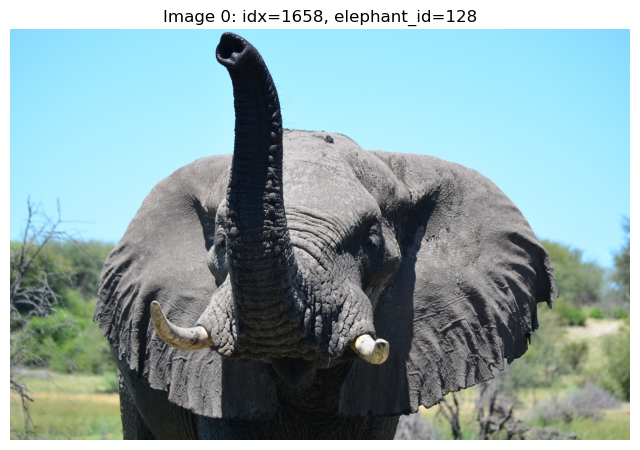

extracted_SEEK=       B00T11E9000-3040X0_S00,
 agg_extracted_SEEK=  B00T11E9080-3040X0_S00, 
 corrected_SEEK=      B00T_1E9000-5040X0_S00, 
 agg_corr_SEEK=       B00T11E8090-3040X00S00, 
 oracle_SEEK=         B00T11E8080-3040X0_S00


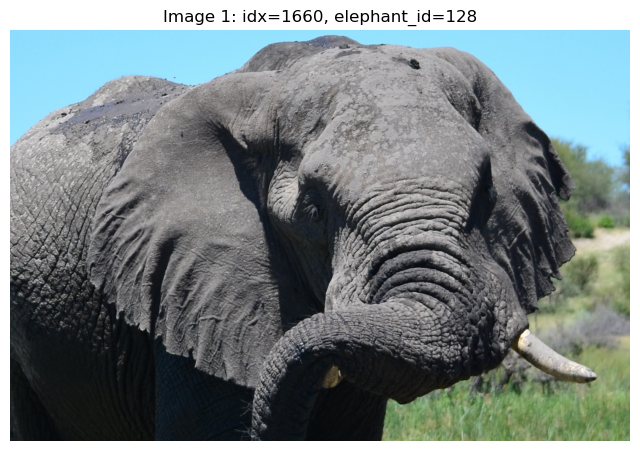

extracted_SEEK=       B00T11E8080-3000X0_S00,
 agg_extracted_SEEK=  B00T11E9080-3040X0_S00, 
 corrected_SEEK=      B00T11E8090-0000X0_S0_, 
 agg_corr_SEEK=       B00T11E8090-3040X00S00, 
 oracle_SEEK=         B00T11E8080-3040X0_S00


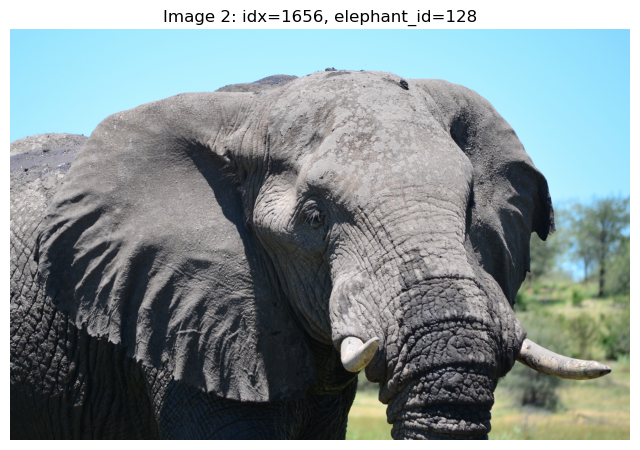

extracted_SEEK=       B00T11E8080-3040X0_S00,
 agg_extracted_SEEK=  B00T11E9080-3040X0_S00, 
 corrected_SEEK=      B00T11E8080-3040X00S00, 
 agg_corr_SEEK=       B00T11E8090-3040X00S00, 
 oracle_SEEK=         B00T11E8080-3040X0_S00


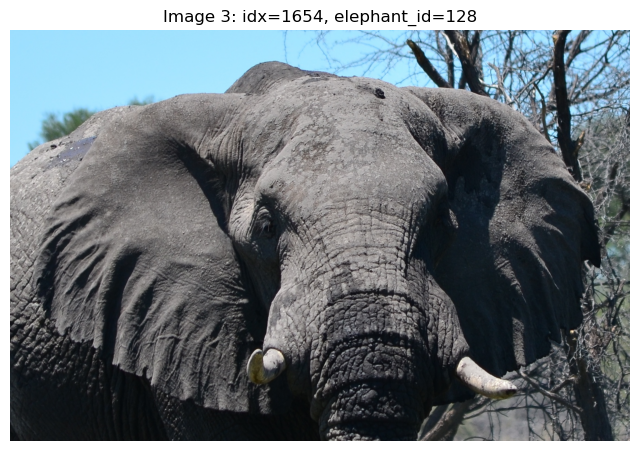

In [ ]:
display_elephant_images(DF, dataset, elephant_id=128)

Elephant ID: 223, Number of images: 5
extracted_SEEK=       B00T11E0000-0000X00S00,
 agg_extracted_SEEK=  B00T11E0000-0000X00S00, 
 corrected_SEEK=      B00T11E0000-0000X00S00, 
 agg_corr_SEEK=       B00T11E9989-0000X00S00, 
 oracle_SEEK=         B00T11E0000-0000X00S00


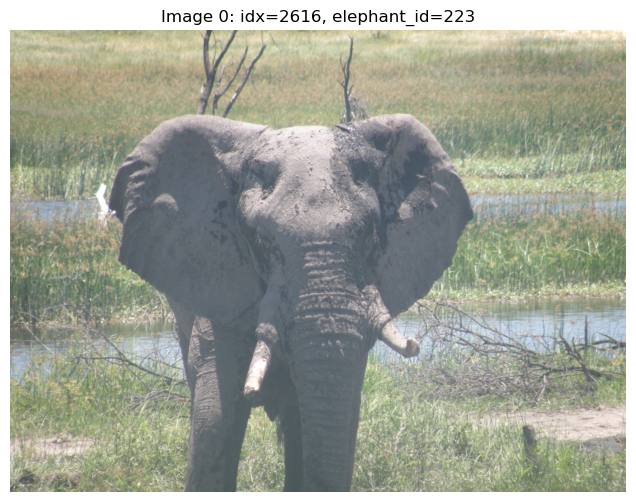

extracted_SEEK=       B00T11E0000-0000X00S00,
 agg_extracted_SEEK=  B00T11E0000-0000X00S00, 
 corrected_SEEK=      B00T11E0000-____X0_S00, 
 agg_corr_SEEK=       B00T11E9989-0000X00S00, 
 oracle_SEEK=         B00T11E0000-0000X00S00


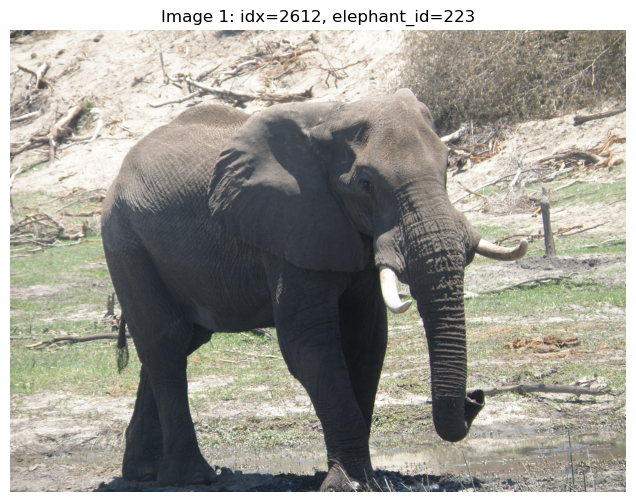

extracted_SEEK=       B00T11E0000-0000X00S00,
 agg_extracted_SEEK=  B00T11E0000-0000X00S00, 
 corrected_SEEK=      B00T11E____-0000X_0S00, 
 agg_corr_SEEK=       B00T11E9989-0000X00S00, 
 oracle_SEEK=         B00T11E0000-0000X00S00


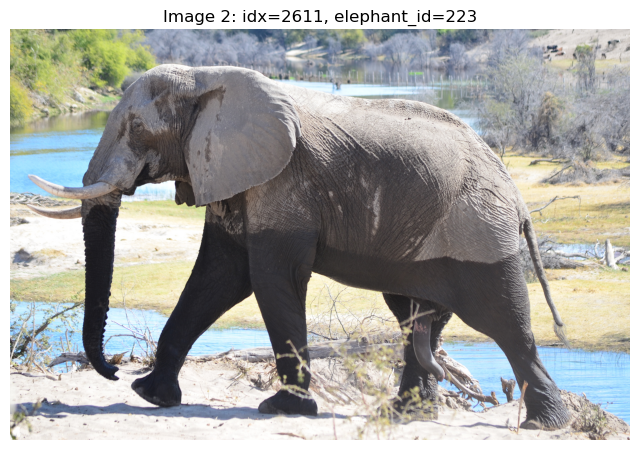

extracted_SEEK=       B00T11E0000-0000X00S00,
 agg_extracted_SEEK=  B00T11E0000-0000X00S00, 
 corrected_SEEK=      B00T11E____-0000X_0S00, 
 agg_corr_SEEK=       B00T11E9989-0000X00S00, 
 oracle_SEEK=         B00T11E0000-0000X00S00


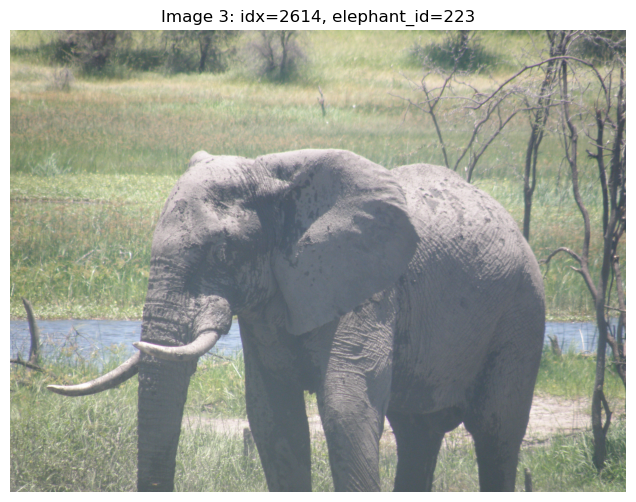

extracted_SEEK=       B00T11E0000-0000X00S00,
 agg_extracted_SEEK=  B00T11E0000-0000X00S00, 
 corrected_SEEK=      B00T11E9989-0500X00S00, 
 agg_corr_SEEK=       B00T11E9989-0000X00S00, 
 oracle_SEEK=         B00T11E0000-0000X00S00


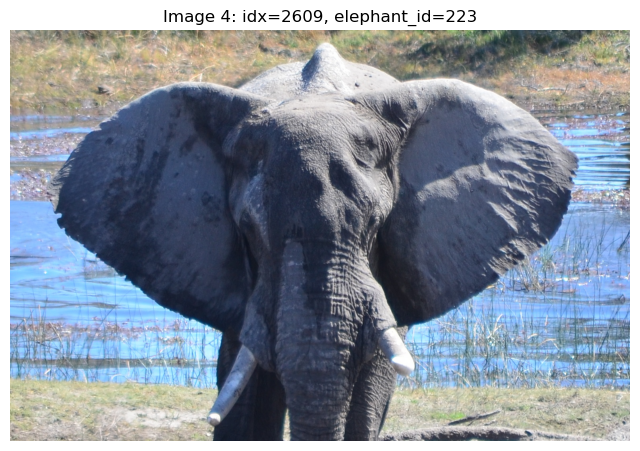

In [ ]:
display_elephant_images(DF, dataset, elephant_id=223)

extracted_SEEK=       B00T11E0000-3000X0_S00,
 agg_extracted_SEEK=  B00T11E0000-3000X00S00, 
 corrected_SEEK=      B00T11E0000-__00X0_S00, 
 agg_corr_SEEK=       B00T11E0000-3400X00S00, 
 oracle_SEEK=         B00T11E0000-3000X00S00


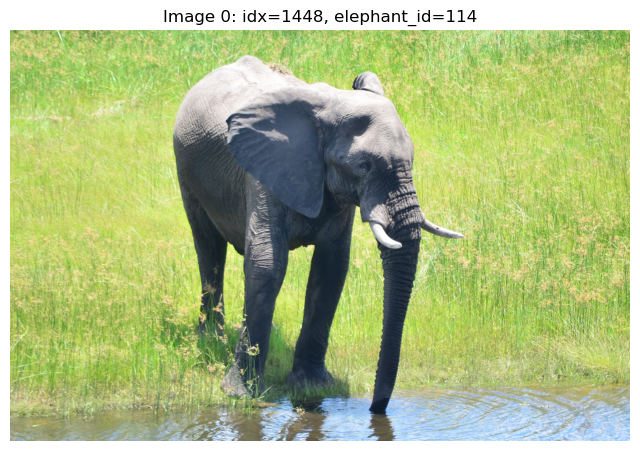

extracted_SEEK=       B00T11E0000-3000X00S00,
 agg_extracted_SEEK=  B00T11E0000-3000X00S00, 
 corrected_SEEK=      B00T11E0000-3400X00S__, 
 agg_corr_SEEK=       B00T11E0000-3400X00S00, 
 oracle_SEEK=         B00T11E0000-3000X00S00


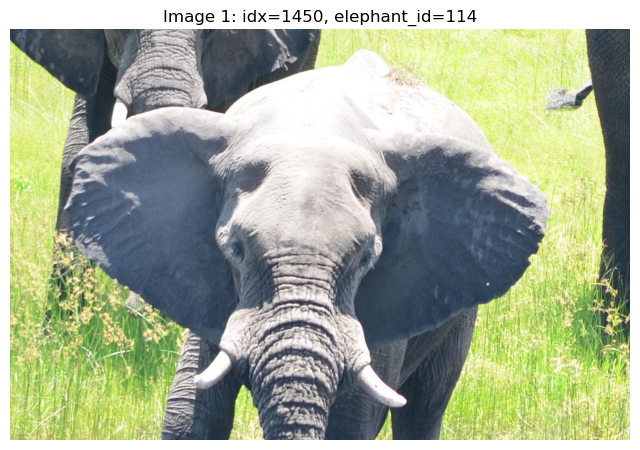

extracted_SEEK=       B00T11E0000-3000X0_S00,
 agg_extracted_SEEK=  B00T11E0000-3000X00S00, 
 corrected_SEEK=      C00T_1E____-3040X_0S00, 
 agg_corr_SEEK=       B00T11E0000-3400X00S00, 
 oracle_SEEK=         B00T11E0000-3000X00S00


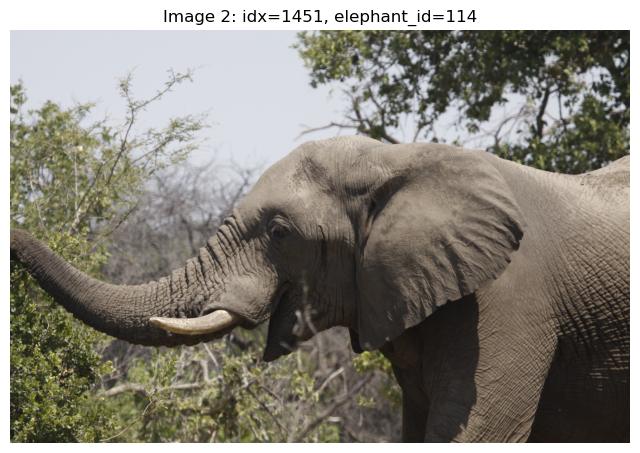

extracted_SEEK=       B00T11E0000-3000X00S00,
 agg_extracted_SEEK=  B00T11E0000-3000X00S00, 
 corrected_SEEK=      B00T11E0000-3000X00S00, 
 agg_corr_SEEK=       B00T11E0000-3400X00S00, 
 oracle_SEEK=         B00T11E0000-3000X00S00


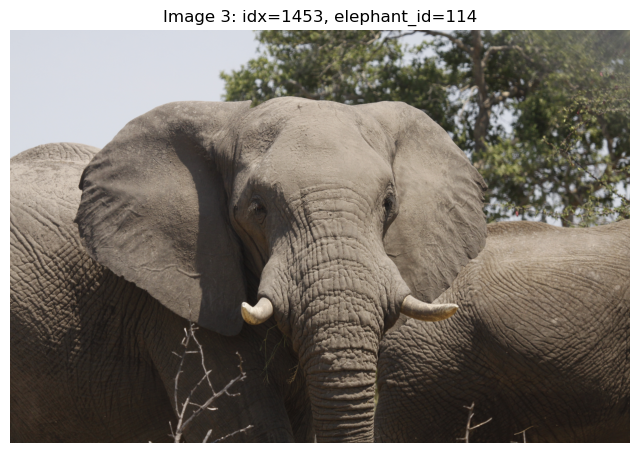

In [ ]:
display_elephant_images(DF, dataset, elephant_id=114)

In [ ]:
distance_DF = collect_all_SEEKs(MD_for_concepts, concept_head, train_loader, device='cuda')

KeyboardInterrupt: 

In [ ]:
distance_DF

,image_idx,ele_id_label,extracted_seek_str,corrected_seek_str,oracle_seek_str,agg_extracted_seek_str,agg_corrected_seek_str
0,1346,102,B00T11E0000-0000X_0S00,B00T11E____-0000X_0S00,B00T11E0000-5000X_0S00,B00T11E0000-0000X_0S00,B00T11E0000-5000X_0S00
1,100,3,B00T11E8000-4000X_0S00,B00T_1E8977-5030X_0S00,B00T01E8070-4330X_0S00,B00T11E8000-4040X_0S00,B00T01E8977-4333X00S00
2,1344,102,B00T11E0000-0000X_0S00,B00T11E0000-0000X00S00,B00T11E0000-5000X_0S00,B00T11E0000-0000X_0S00,B00T11E0000-5000X_0S00
3,2657,229,B00T11E9080-0000X__S00,B00T11E____-0000X_0S00,B00T11E8080-0000X__S00,B00T11E8080-0000X__S00,B00T11E9080-0000X00S00
4,1980,157,B00T11E0000-0000X0_S00,B00T11E0000-0000X0_S00,B00T11E9000-0000X0_S00,B00T11E9000-0000X0_S00,B00T11E9000-4000X00S00
...,...,...,...,...,...,...,...
1976,2587,220,B00T11E0000-3000X_0S00,B00T_0E____-4050X_0S00,B00T10E9090-3040X_0S0_,B00T11E9000-3040X_0S00,B00T10E8897-3040X_0S00
1977,113,4,B00T11E0000-3000X0_S00,B20T1_E0000-0000X0_S00,B00T11E8000-3000X0_S00,B00T11E8000-3000X0_S00,B00T11E7790-3000X00S00
1978,759,57,B00T11E0000-0000X_0S00,B00T11E____-0000X_0S00,B00T1_E0700-0300X_0S00,B00T11E0000-0000X_0S00,B00T11E0700-0300X_0S00
1979,2640,226,B00T11E0000-0000X0_S00,B00T11E0000-5435X0_S00,B00T11E0000-0000X0_S00,B00T11E0000-0000X0_S00,B00T11E9000-3435X00S00


In [ ]:
distance_DF['label_to_oracle'] = distance_DF.apply(lambda row: SEEK.distance_3(SEEK(row['extracted_seek_str']), SEEK(row['oracle_seek_str'])), axis=1)

In [ ]:
distance_DF['agg_label_to_oracle'] = distance_DF.apply(lambda row: SEEK.distance_3(SEEK(row['agg_corrected_seek_str']), SEEK(row['oracle_seek_str'])), axis=1)

In [ ]:
distance_DF.head(50)

,image_idx,ele_id_label,extracted_seek_str,corrected_seek_str,oracle_seek_str,agg_extracted_seek_str,agg_corrected_seek_str,label_to_oracle,agg_label_to_oracle
0,1346,102,B00T11E0000-0000X_0S00,B00T11E____-0000X_0S00,B00T11E0000-5000X_0S00,B00T11E0000-0000X_0S00,B00T11E0000-5000X_0S00,5.0,0.0
1,100,3,B00T11E8000-4000X_0S00,B00T_1E8977-5030X_0S00,B00T01E8070-4330X_0S00,B00T11E8000-4040X_0S00,B00T01E8977-4333X00S00,14.0,19.2
2,1344,102,B00T11E0000-0000X_0S00,B00T11E0000-0000X00S00,B00T11E0000-5000X_0S00,B00T11E0000-0000X_0S00,B00T11E0000-5000X_0S00,5.0,0.0
3,2657,229,B00T11E9080-0000X__S00,B00T11E____-0000X_0S00,B00T11E8080-0000X__S00,B00T11E8080-0000X__S00,B00T11E9080-0000X00S00,1.0,1.4
4,1980,157,B00T11E0000-0000X0_S00,B00T11E0000-0000X0_S00,B00T11E9000-0000X0_S00,B00T11E9000-0000X0_S00,B00T11E9000-4000X00S00,9.0,4.2
5,543,39,B00T11E8080-3040X_0S00,B00T__E9988-____X0_S_0,B00T11E7080-3540X_0S00,B00T11E8080-3040X_0S00,B00T11E9080-3444X00S00,6.0,7.2
6,1446,113,B00T11E9000-0000X0_S00,B00T1_E0000-____X0_S00,B00T11E8000-0000X0_S00,B00T11E9000-0000X0_S00,B00T11E9000-3000X00S00,1.0,4.2
7,201,10,B00T11E0000-3000X00S00,B00T__E9000-0000X00S00,B00T11E0000-3000X00S00,B00T11E0000-3000X00S00,B00T11E8000-3000X00S00,0.0,8.0
8,408,25,B00T11E9000-4000X_0S00,B00T11E____-3040X_0S00,B00T11E9000-4030X_0S00,B00T11E9000-4000X_0S00,B00T11E8080-4350X00S00,3.0,14.2
9,2146,172,B00T11E0000-0000X__S00,B00T_1E____-4000X_0S00,B00T11E0000-4000X__S00,B00T11E0000-4000X__S00,B00T11E0000-3000X00S00,4.0,1.4


# Examples after optimization of the aggregation strategy

Elephant ID: 3, Number of images: 4
extracted_SEEK=       B00T11E8000-4000X_0S00,
 agg_extracted_SEEK=  B00T11E8000-4030X_0S00, 
 corrected_SEEK=      B00T_1E____-50__X_0S00, 
 agg_corr_SEEK=       B00T01E8070-4333X00S00, 
 oracle_SEEK=         B00T01E8070-4330X_0S00


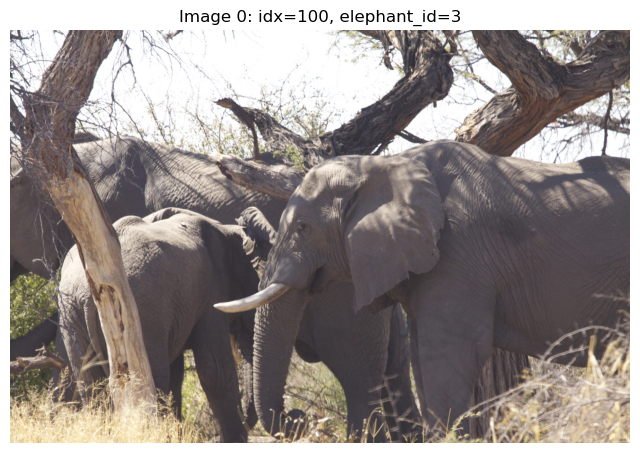

extracted_SEEK=       B00T11E8000-4030X_0S00,
 agg_extracted_SEEK=  B00T11E8000-4030X_0S00, 
 corrected_SEEK=      B00T0_E8000-4333X00S00, 
 agg_corr_SEEK=       B00T01E8070-4333X00S00, 
 oracle_SEEK=         B00T01E8070-4330X_0S00


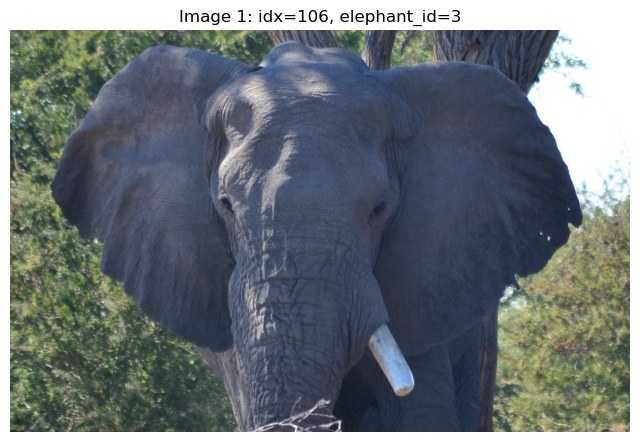

extracted_SEEK=       B00T_1E8000-4040X_0S00,
 agg_extracted_SEEK=  B00T11E8000-4030X_0S00, 
 corrected_SEEK=      B00T01E8070-____X0_S00, 
 agg_corr_SEEK=       B00T01E8070-4333X00S00, 
 oracle_SEEK=         B00T01E8070-4330X_0S00


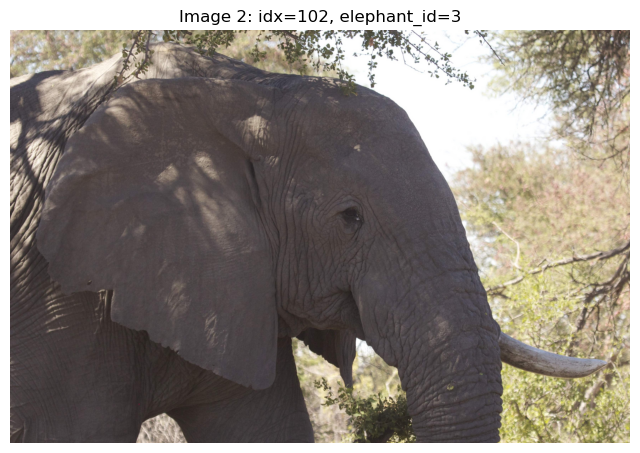

extracted_SEEK=       B00T11E8080-4000X_0S00,
 agg_extracted_SEEK=  B00T11E8000-4030X_0S00, 
 corrected_SEEK=      B00T01E____-4000X_0S00, 
 agg_corr_SEEK=       B00T01E8070-4333X00S00, 
 oracle_SEEK=         B00T01E8070-4330X_0S00


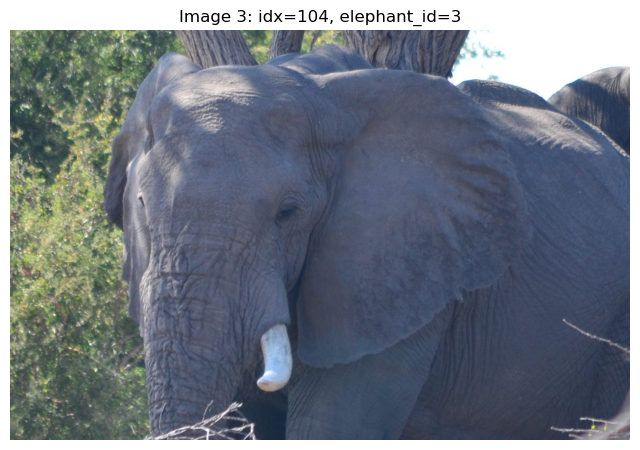

In [12]:
dataset_with_opt_labels = EleHandler(subset='IDI_6', dictonary_path='/data/vision/beery/scratch/antoine/CBM_reid/data_processing/data/out_apr2/image_dictonary_optimized.csv')
train_indices, test_indices = dataset_with_opt_labels.split_perpendicular_to_elephants_and_encounters(split_sizes=[0.5,0.5], hour_delta = 0.2)
train_subset = Subset(dataset_with_opt_labels, train_indices)
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
DF = collect_all_SEEKs(MD_for_concepts, concept_head, train_loader, device='cuda')
display_elephant_images(DF, dataset_with_opt_labels, elephant_id=3)

Elephant ID: 3, Number of images: 4
extracted_SEEK=       B00T_1E8000-4040X_0S00,
 agg_extracted_SEEK=  B00T11E8000-4040X_0S00, 
 corrected_SEEK=      B00T01E8070-____X0_S00, 
 agg_corr_SEEK=       B00T01E8977-4333X00S00, 
 oracle_SEEK=         B00T01E8070-4330X_0S00


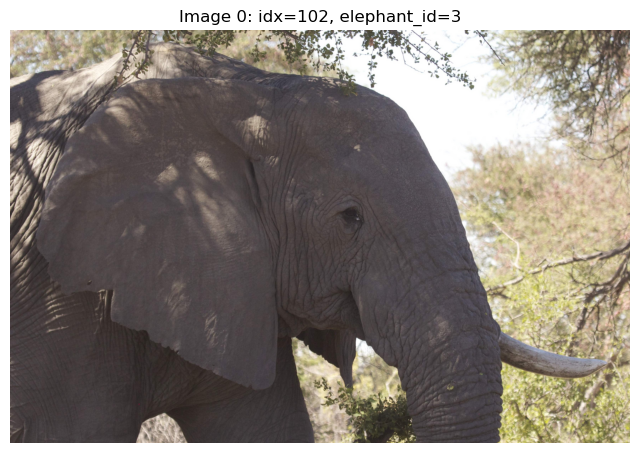

extracted_SEEK=       B00T11E8080-4000X_0S00,
 agg_extracted_SEEK=  B00T11E8000-4040X_0S00, 
 corrected_SEEK=      B00T01E____-4000X_0S00, 
 agg_corr_SEEK=       B00T01E8977-4333X00S00, 
 oracle_SEEK=         B00T01E8070-4330X_0S00


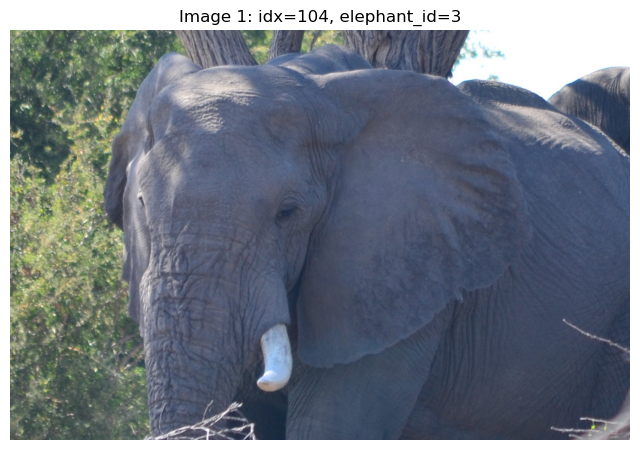

extracted_SEEK=       B00T11E8000-4030X_0S00,
 agg_extracted_SEEK=  B00T11E8000-4040X_0S00, 
 corrected_SEEK=      B00T0_E8000-4333X00S00, 
 agg_corr_SEEK=       B00T01E8977-4333X00S00, 
 oracle_SEEK=         B00T01E8070-4330X_0S00


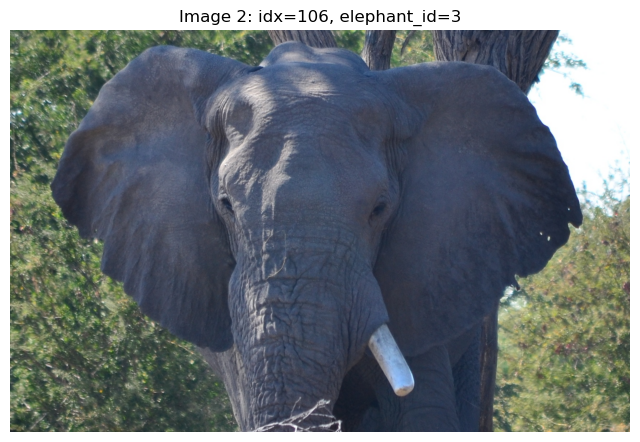

extracted_SEEK=       B00T11E8000-4000X_0S00,
 agg_extracted_SEEK=  B00T11E8000-4040X_0S00, 
 corrected_SEEK=      B00T_1E8977-5030X_0S00, 
 agg_corr_SEEK=       B00T01E8977-4333X00S00, 
 oracle_SEEK=         B00T01E8070-4330X_0S00


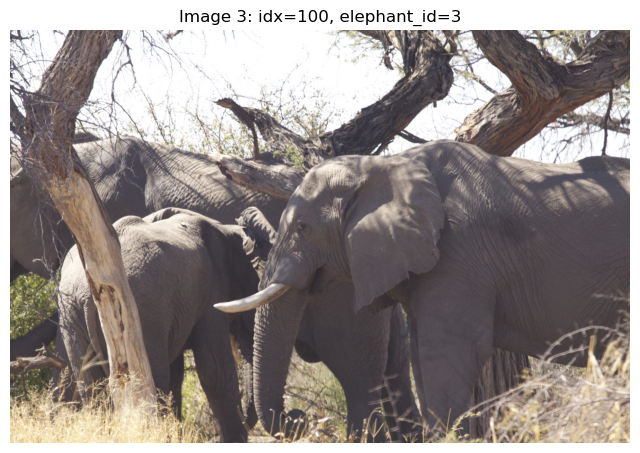

In [13]:
dataset = EleHandler(subset='IDI_6', dictonary_path='/data/vision/beery/scratch/antoine/CBM_reid/data_processing/data/out_apr2/image_dictonary_original.csv')
train_indices, test_indices = dataset.split_perpendicular_to_elephants_and_encounters(split_sizes=[0.5,0.5], hour_delta = 0.2)
train_subset = Subset(dataset, train_indices)
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
DF = collect_all_SEEKs(MD_for_concepts, concept_head, train_loader, device='cuda')
display_elephant_images(DF, dataset, elephant_id=3)